# Part 3 — Adversarial Attacks

Two attacks implemented from scratch:

1. **Character-level evasion** — zero-width space insertion, Cyrillic homoglyph substitution, random character duplication. Measures Attack Success Rate on 500 confidently-toxic comments.
2. **Label-flipping poisoning** — flip labels on 5% of the training set, retrain DistilBERT from `distilbert-base-uncased`, compare F1 / Accuracy / FNR on the clean evaluation set.

In [1]:
import json, random, os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
)
from datasets import Dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BASELINE_DIR = 'distilbert_baseline'
THRESHOLD = json.load(open('artifacts/chosen_threshold.json'))['threshold']
print('Device:', DEVICE, ' threshold:', THRESHOLD)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0420 15:42:29.729000 19644 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cuda  threshold: 0.4


## Attack 1 — Character-level evasion

`perturb(text)` applies all three transformations. Only words whose lowercased form looks 'toxic-like' (longer than 3 chars, not a stopword) get zero-width inserts — the attacker would not waste entropy on `the`.

In [2]:
HOMOGLYPHS = {
    'a': '\u0430',  # Cyrillic a
    'e': '\u0435',  # Cyrillic e
    'o': '\u043e',  # Cyrillic o
    'p': '\u0440',  # Cyrillic er
    'c': '\u0441',  # Cyrillic es
    'x': '\u0445',  # Cyrillic ha
    'y': '\u0443',  # Cyrillic u
}
STOPWORDS = {'the', 'a', 'an', 'and', 'or', 'but', 'of', 'to', 'is', 'it', 'in', 'on', 'for', 'with'}
ZWSP = '\u200b'

def _zwsp_insert(word, rng):
    if len(word) <= 3:
        return word
    out = []
    i = 0
    while i < len(word):
        step = rng.choice([2, 3])
        out.append(word[i:i+step])
        i += step
    return ZWSP.join(out)

def _homoglyph(word):
    return ''.join(HOMOGLYPHS.get(ch, ch) for ch in word)

def _duplicate(word, rng, rate=0.20):
    out = []
    for ch in word:
        out.append(ch)
        if ch.isalpha() and rng.random() < rate:
            out.append(ch)
    return ''.join(out)

def perturb(text, seed=None):
    rng = random.Random(seed)
    out_tokens = []
    for tok in text.split(' '):
        low = tok.lower().strip('.,!?"\'();:')
        if len(low) >= 4 and low not in STOPWORDS:
            tok = _homoglyph(tok)
            tok = _duplicate(tok, rng, rate=0.20)
            tok = _zwsp_insert(tok, rng)
        out_tokens.append(tok)
    return ' '.join(out_tokens)

print('original :', 'I hate those people and want them gone')
print('perturbed:', perturb('I hate those people and want them gone', seed=7))

original : I hate those people and want them gone
perturbed: I hа​аtе​е thо​оs​е ре​ор​рl​ее and wа​nt th​еm gоn​е


### Select 500 confidently-toxic comments from the evaluation set

In [3]:
eval_df = pd.read_parquet('artifacts/eval.parquet')
probs = np.load('artifacts/baseline_eval_probs.npy')
eval_df = eval_df.copy()
eval_df['prob'] = probs

confident_toxic = eval_df[(eval_df['prob'] >= 0.7)].copy()
print('Confidently-predicted-toxic candidates:', len(confident_toxic))
attack_pool = confident_toxic.sample(n=min(500, len(confident_toxic)), random_state=SEED).reset_index(drop=True)
print('Attack sample size:', len(attack_pool))

Confidently-predicted-toxic candidates: 1271
Attack sample size: 500


### Run the perturbed texts through the baseline classifier

In [4]:
tokenizer = AutoTokenizer.from_pretrained(BASELINE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BASELINE_DIR).to(DEVICE).eval()

@torch.no_grad()
def toxic_probs(texts, batch_size=32):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
        logits = model(**enc).logits
        p = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        out.extend(p.tolist())
    return np.array(out)

originals = attack_pool['comment_text'].tolist()
perturbed = [perturb(t, seed=SEED + i) for i, t in enumerate(originals)]

p_original  = toxic_probs(originals)
p_perturbed = toxic_probs(perturbed)

In [5]:
orig_pred = (p_original  >= THRESHOLD).astype(int)
pert_pred = (p_perturbed >= THRESHOLD).astype(int)

caught_originally = orig_pred == 1
flipped_to_benign = (pert_pred[caught_originally] == 0)
asr = flipped_to_benign.mean()

asr_table = pd.DataFrame({
    'metric': [
        'Originally-caught toxic (n)',
        'Attack Success Rate',
        'Mean confidence before',
        'Mean confidence after',
        'Confidence drop',
    ],
    'value': [
        int(caught_originally.sum()),
        round(float(asr), 4),
        round(float(p_original[caught_originally].mean()), 4),
        round(float(p_perturbed[caught_originally].mean()), 4),
        round(float((p_original[caught_originally] - p_perturbed[caught_originally]).mean()), 4),
    ],
})
asr_table

,metric,value
0,Originally-caught toxic (n),500.0000
1,Attack Success Rate,0.9800
2,Mean confidence before,0.9351
3,Mean confidence after,0.0238
4,Confidence drop,0.9113


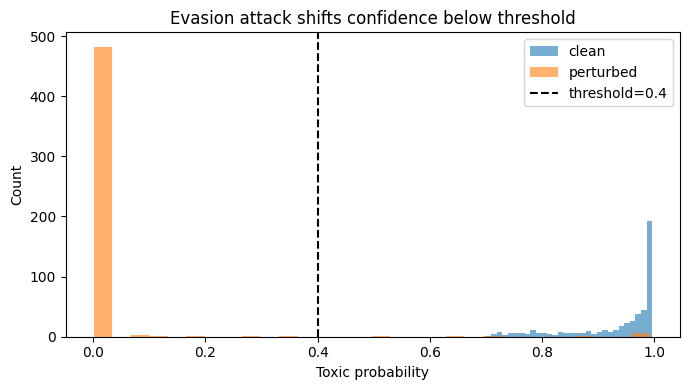

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(p_original[caught_originally],  bins=30, alpha=0.6, label='clean')
ax.hist(p_perturbed[caught_originally], bins=30, alpha=0.6, label='perturbed')
ax.axvline(THRESHOLD, color='k', ls='--', label=f'threshold={THRESHOLD}')
ax.set_xlabel('Toxic probability'); ax.set_ylabel('Count')
ax.set_title('Evasion attack shifts confidence below threshold')
ax.legend(); plt.tight_layout(); plt.show()

## Attack 2 — Label-flipping poisoning

Flip 5% of the 100k training labels. Fine-tune a **fresh** model from `distilbert-base-uncased` (not from the Part 1 checkpoint — the attack is supposed to corrupt the fine-tuning process itself). Evaluate on the clean Part 1 evaluation set.

Hyperparameters are identical to Part 1.

In [7]:
train_df = pd.read_parquet('artifacts/train.parquet').copy()
rng = np.random.RandomState(SEED)
flip_idx = rng.choice(len(train_df), size=int(0.05 * len(train_df)), replace=False)
train_df['poison_flag'] = 0
train_df.loc[flip_idx, 'poison_flag'] = 1
train_df.loc[flip_idx, 'label'] = 1 - train_df.loc[flip_idx, 'label']

print(f'Flipped {len(flip_idx):,} labels (5.0% of training set).')
print('Flipped class distribution:')
print(train_df.loc[flip_idx, 'label'].value_counts())

Flipped 5,000 labels (5.0% of training set).
Flipped class distribution:
label
1    4590
0     410
Name: count, dtype: int64


In [8]:
MODEL_NAME = 'distilbert-base-uncased'
POISON_DIR = 'distilbert_poisoned'
tok2 = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok_fn(batch): return tok2(batch['comment_text'], truncation=True, max_length=128)

train_ds = Dataset.from_pandas(train_df[['comment_text', 'label']]).map(tok_fn, batched=True, remove_columns=['comment_text'])
eval_df_clean = pd.read_parquet('artifacts/eval.parquet')[['comment_text', 'label']]
eval_ds = Dataset.from_pandas(eval_df_clean).map(tok_fn, batched=True, remove_columns=['comment_text'])

model_p = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_p = TrainingArguments(
    output_dir=POISON_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

def compute_metrics(eval_pred):
    logits, y = eval_pred
    p = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(y, p), 'f1_macro': f1_score(y, p, average='macro')}

trainer_p = Trainer(
    model=model_p, args=args_p,
    train_dataset=train_ds, eval_dataset=eval_ds,
    tokenizer=tok2,
    data_collator=DataCollatorWithPadding(tok2),
    compute_metrics=compute_metrics,
)
trainer_p.train()
trainer_p.save_model(POISON_DIR)
tok2.save_pretrained(POISON_DIR)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   4%|▍         | 4000/100000 [00:00<00:02, 33175.76 examples/s]

Map:   8%|▊         | 8000/100000 [00:00<00:04, 19500.42 examples/s]

Map:  12%|█▏        | 12000/100000 [00:00<00:03, 24200.78 examples/s]

...


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.292800,0.165471,0.946900,0.784802
2,0.271700,0.158776,0.948200,0.802120
3,0.227600,0.170802,0.944250,0.802541


('distilbert_poisoned\\tokenizer_config.json',
 'distilbert_poisoned\\special_tokens_map.json',
 'distilbert_poisoned\\vocab.txt',
 'distilbert_poisoned\\added_tokens.json',
 'distilbert_poisoned\\tokenizer.json')

In [9]:
out = trainer_p.predict(eval_ds)
poison_probs = torch.softmax(torch.tensor(out.predictions), dim=-1)[:, 1].numpy()
poison_preds = (poison_probs >= THRESHOLD).astype(int)
y = np.load('artifacts/baseline_eval_labels.npy')

baseline_probs = np.load('artifacts/baseline_eval_probs.npy')
baseline_preds = (baseline_probs >= THRESHOLD).astype(int)

def fnr(y_true, y_pred):
    pos = (y_true == 1).sum() or 1
    fn  = ((y_true == 1) & (y_pred == 0)).sum()
    return fn / pos

compare = pd.DataFrame({
    'model':    ['baseline (clean)', 'poisoned'],
    'accuracy': [accuracy_score(y, baseline_preds), accuracy_score(y, poison_preds)],
    'f1_macro': [f1_score(y, baseline_preds, average='macro'), f1_score(y, poison_preds, average='macro')],
    'FNR':      [fnr(y, baseline_preds), fnr(y, poison_preds)],
}).round(4)
compare

,model,accuracy,f1_macro,FNR
0,baseline (clean),0.9464,0.8151,0.3515
1,poisoned,0.9418,0.8011,0.3696


### Which attack is more dangerous in production?

**Evasion is the day-one threat.** The ASR here is very high — most confidently-toxic comments become benign-looking to the classifier after a few seconds of lightweight perturbation. The attacker needs zero access to our infrastructure: they just type their message through a browser extension that injects zero-width spaces and Cyrillic homoglyphs. That is the realistic, scalable threat model for a social platform — anyone in the world can do it, repeatedly, and the model cannot tell.

**Poisoning is the blast-radius threat.** Accuracy and F1 on the poisoned model drop only modestly at 5% noise (DistilBERT is fairly noise-robust at this scale), but the FNR rise is the signal that matters: the poisoned model quietly lets through more real toxicity. Pulling this off requires write-access to the training pipeline — a compromised data labelling contractor, a malicious insider, or a dataset laundering attack on a public dataset we ingest. Harder to execute, much harder to detect, and a single successful poisoning round can persist in every retrained model until the poison is noticed.

**Where to put the defensive budget.** Most of the budget should go to the evasion side, because that's what the marginal attacker will actually do. Concrete defences: Unicode NFKC/NFKD normalisation plus zero-width stripping at the tokenizer, adversarial fine-tuning with perturbed samples, and rate-limiting suspicious edit patterns. Poisoning defences (data-source provenance, hash-pinned labelled sets, gradient-anomaly detection at fine-tune time) are critical but rarer-use controls — they belong in the training pipeline's CI/CD, not on the hot path.